In [2]:
!pip install scikit-learn==1.9.0

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("apartments_for_rent_classified_10K.csv", sep=";", encoding="latin1")
features = ['price', 'bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude', 'has_photo', 'state', 'price_type']
df = df[features].dropna()
df = df[df['price'] > 0]
df['price_category'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])


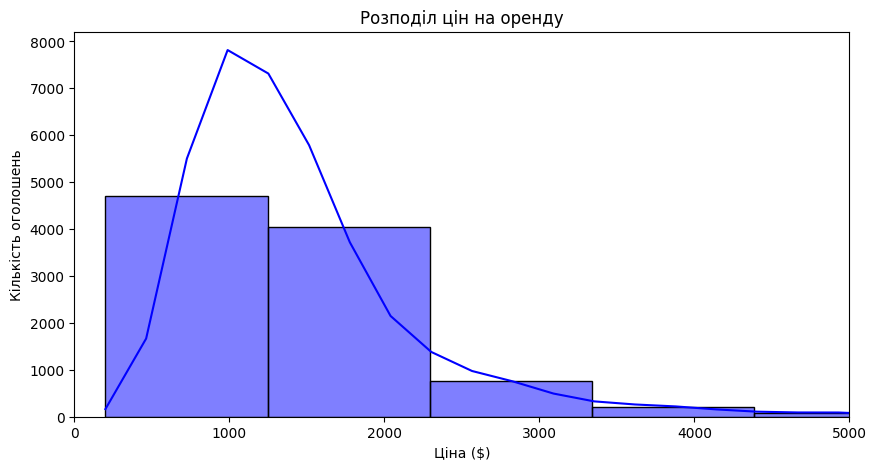

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title("Розподіл цін на оренду")
plt.xlabel("Ціна ($)")
plt.ylabel("Кількість оголошень")
plt.xlim(0, 5000)
plt.show()

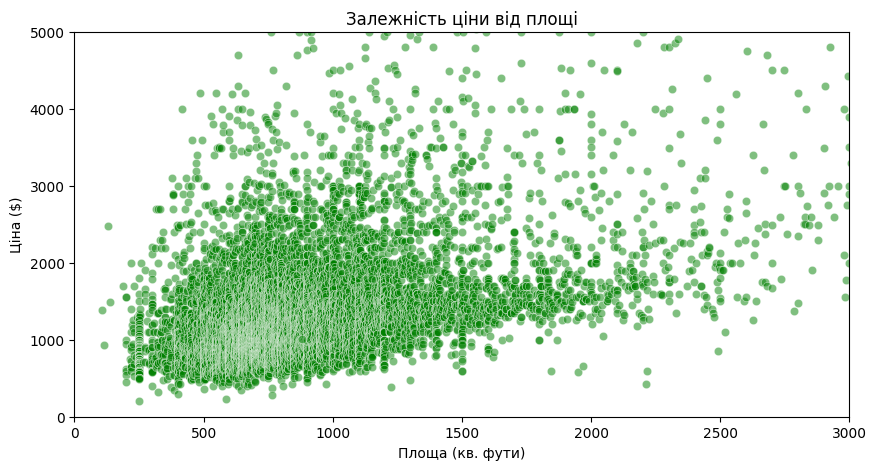

In [5]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='square_feet', y='price', data=df, alpha=0.5, color='green')
plt.title("Залежність ціни від площі")
plt.xlabel("Площа (кв. фути)")
plt.ylabel("Ціна ($)")
plt.xlim(0, 3000)
plt.ylim(0, 5000)
plt.show()

/tmp/ipykernel_2179/1428855096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='state', y='price', data=df_top_states, palette="viridis")


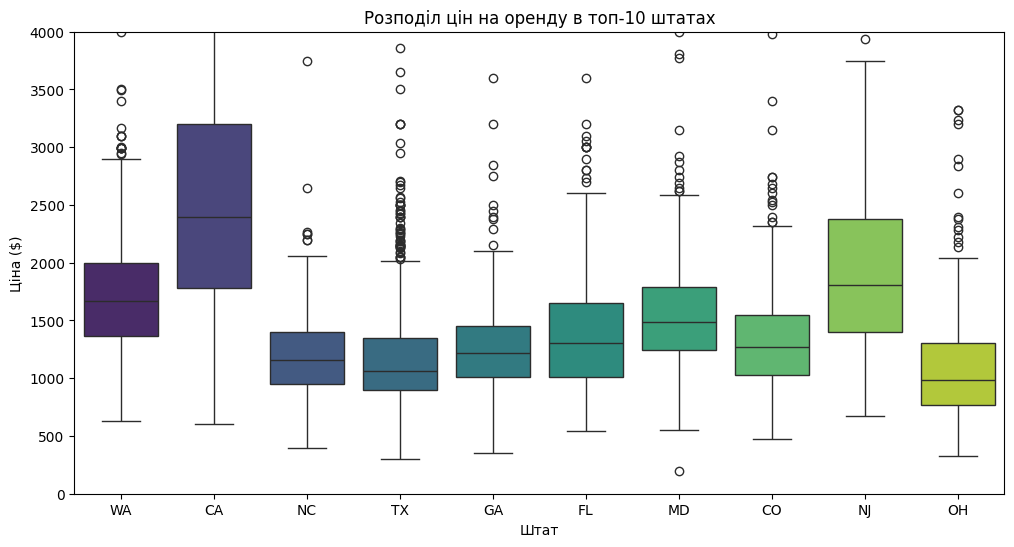

In [6]:
plt.figure(figsize=(12, 6))
top_states = df['state'].value_counts().head(10).index
df_top_states = df[df['state'].isin(top_states)]
sns.boxplot(x='state', y='price', data=df_top_states, palette="viridis")
plt.title("Розподіл цін на оренду в топ-10 штатах")
plt.xlabel("Штат")
plt.ylabel("Ціна ($)")
plt.ylim(0, 4000)
plt.show()

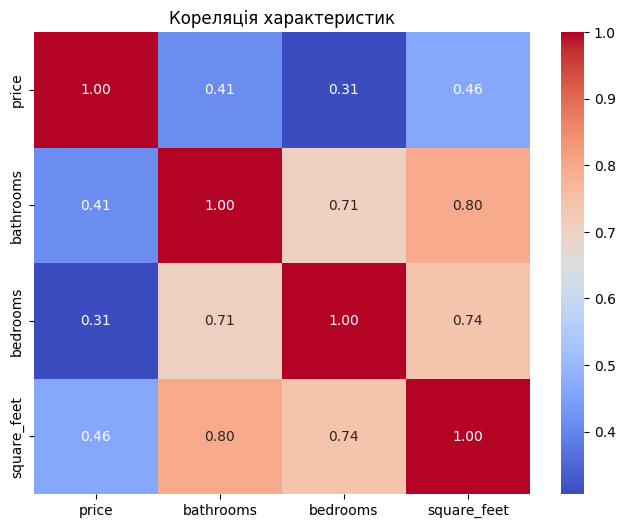

In [7]:
plt.figure(figsize=(8, 6))
numeric_cols = ['price', 'bathrooms', 'bedrooms', 'square_feet']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Кореляція характеристик")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import joblib

X = df.drop(['price', 'price_category'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude']),
    ('cat', cat_transformer, ['has_photo', 'state', 'price_type'])
])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(model_pipeline, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
joblib.dump(best_model, 'rent_model.pkl')
print("Модель збережено.")

Шукаємо найкращі налаштування. Це триватиме кілька хвилин...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Знайдено ідеальні параметри: {'regressor__max_depth': 20, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 150}
Оптимізовану модель збережено.


In [11]:
from sklearn.metrics import mean_absolute_error, r2_score

predictions = grid_search.best_estimator_.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Середня похибка: {int(mae)}$")
print(f"Точність: {round(r2 * 100, 1)}%")

Середня похибка: 247 $
Точність: 71.6%
